In [62]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews
from datetime import datetime

import os

from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline,DistilBertTokenizer

In [1]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))'''

"gn = GNews(language='en', country='US', max_results=5)\n\n# Top news\ntop = gn.get_top_news()\n\n# Search by keyword\nresults = gn.get_news('artificial intelligence')\n\n# By topic\ntech_news = gn.get_news_by_topic('TECHNOLOGY')\n\n# By location\nindia_news = gn.get_news_by_location('India')\n\n# Full article\narticle = gn.get_full_article(results[0]['url'])\nprint(article.text))"

In [82]:
def acquire_news_keyword(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

def acquire_news_top(results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_top_news()

def acquire_news_topic(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

#drops all rows that present in old_news
def filter_new_news(new_news:pd.DataFrame,old_news:pd.DataFrame):
    x=0
    for index,title in enumerate(new_news.iloc[:,0]):
        if title in old_news.iloc[:,0].values:
            new_news.drop(index=index,axis=1,inplace=True)
            x=x+1
        else:
            pass
    print('Total news dropped:',x)

def record_news(new_news:pd.DataFrame,ticker:str,header:bool = False):
    new_news.to_csv(rf"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\{ticker}.csv",header=header,index=False,mode='a')

def acquire_sentiment(new_news:pd.DataFrame):
    model_ckpt = "ProsusAI/finbert"
    classifier = pipeline('text-classification', model=model_ckpt)

    _ = [classifier(text, return_all_scores=True) for text in new_news.iloc[:, 1]]
    new_news['label'] = [res[0]['label'] for res in _]
    new_news['confidence'] = [res[0]['score'] for res in _]
    print(_)
    _.clear()


In [63]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"

In [19]:
news_df=pd.read_csv(path+'/.csv')
news_df.head(10)

In [20]:
news_df.head()

,title,description,published date,url,publisher
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The..."
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':..."
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N..."
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title..."
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ..."


In [21]:
news_df.shape

(180, 5)

In [22]:
ndf=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))

In [23]:
ndf.head()

,title,description,published date,url,publisher
0,Less AI? Microsoft Pledges to Focus on Windows...,Less AI? Microsoft Pledges to Focus on Windows...,"Sun, 22 Mar 2026 21:50:17 GMT",https://news.google.com/rss/articles/CBMiowFBV...,"{'href': 'https://www.pcmag.com', 'title': 'PC..."
1,TD SYNNEX Achieves Microsoft’s Newly Establish...,TD SYNNEX Achieves Microsoft’s Newly Establish...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiiwFBV...,"{'href': 'https://au.finance.yahoo.com', 'titl..."
2,"Microsoft reinstated, Ralph Lauren upgraded: W...","Microsoft reinstated, Ralph Lauren upgraded: W...","Tue, 24 Mar 2026 13:36:48 GMT",https://news.google.com/rss/articles/CBMiqwFBV...,"{'href': 'https://finance.yahoo.com', 'title':..."
3,Microsoft president says winning trust of US c...,Microsoft president says winning trust of US c...,"Tue, 24 Mar 2026 15:13:54 GMT",https://news.google.com/rss/articles/CBMiqwFBV...,"{'href': 'https://finance.yahoo.com', 'title':..."
4,OpenAI calls out Microsoft reliance as risk in...,OpenAI calls out Microsoft reliance as risk in...,"Mon, 23 Mar 2026 23:00:28 GMT",https://news.google.com/rss/articles/CBMipAFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}"


In [24]:
ndf.shape

(100, 5)

In [25]:
filter_new_news(new_news=ndf,old_news=news_df)

Total news dropped: 60


In [26]:
ndf.shape

(40, 5)

In [27]:
ndf.head()

,title,description,published date,url,publisher
2,"Microsoft reinstated, Ralph Lauren upgraded: W...","Microsoft reinstated, Ralph Lauren upgraded: W...","Tue, 24 Mar 2026 13:36:48 GMT",https://news.google.com/rss/articles/CBMiqwFBV...,"{'href': 'https://finance.yahoo.com', 'title':..."
3,Microsoft president says winning trust of US c...,Microsoft president says winning trust of US c...,"Tue, 24 Mar 2026 15:13:54 GMT",https://news.google.com/rss/articles/CBMiqwFBV...,"{'href': 'https://finance.yahoo.com', 'title':..."
5,"After billions of funding and multi-year deal,...","After billions of funding and multi-year deal,...","Tue, 24 Mar 2026 06:18:00 GMT",https://news.google.com/rss/articles/CBMigAJBV...,{'href': 'https://timesofindia.indiatimes.com'...
12,This Microsoft security team stress-tests AI f...,This Microsoft security team stress-tests AI f...,"Tue, 24 Mar 2026 15:39:47 GMT",https://news.google.com/rss/articles/CBMifkFVX...,"{'href': 'https://www.fastcompany.com', 'title..."
14,Microsoft Stock (MSFT) Opinions on OpenAI IPO ...,Microsoft Stock (MSFT) Opinions on OpenAI IPO ...,"Tue, 24 Mar 2026 14:03:00 GMT",https://news.google.com/rss/articles/CBMipAFBV...,"{'href': 'https://www.quiverquant.com', 'title..."


In [28]:
record_news(ndf,header=False)

In [29]:
del news_df

In [79]:
news_df=pd.read_csv(path+'\\NVIDIA.csv')
news_df.head()

,title,description,published date,url,publisher,time_of_collection
0,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,"Mon, 23 Mar 2026 23:37:35 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.forbes.com', 'title': 'F...",2026-03-24 22:29
1,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,"Mon, 23 Mar 2026 19:42:33 GMT",https://news.google.com/rss/articles/CBMiigFBV...,"{'href': 'https://www.theverge.com', 'title': ...",2026-03-24 22:29
2,NVIDIA CEO Jensen Huang says AGI is here — sor...,NVIDIA CEO Jensen Huang says AGI is here — sor...,"Tue, 24 Mar 2026 16:11:53 GMT",https://news.google.com/rss/articles/CBMifEFVX...,"{'href': 'https://mashable.com', 'title': 'Mas...",2026-03-24 22:29
3,Super Micro’s Fate Lies in Nvidia’s Hands - WSJ,Super Micro’s Fate Lies in Nvidia’s Hands WSJ,"Tue, 24 Mar 2026 09:30:00 GMT",https://news.google.com/rss/articles/CBMikANBV...,"{'href': 'https://www.wsj.com', 'title': 'WSJ'}",2026-03-24 22:29
4,Microsoft and Nvidia team up on AI nuclear pus...,Microsoft and Nvidia team up on AI nuclear pus...,"Tue, 24 Mar 2026 16:03:38 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.axios.com', 'title': 'Ax...",2026-03-24 22:29


In [80]:
news_df.head(10)

,title,description,published date,url,publisher,time_of_collection
0,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,"Mon, 23 Mar 2026 23:37:35 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.forbes.com', 'title': 'F...",2026-03-24 22:29
1,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,"Mon, 23 Mar 2026 19:42:33 GMT",https://news.google.com/rss/articles/CBMiigFBV...,"{'href': 'https://www.theverge.com', 'title': ...",2026-03-24 22:29
2,NVIDIA CEO Jensen Huang says AGI is here — sor...,NVIDIA CEO Jensen Huang says AGI is here — sor...,"Tue, 24 Mar 2026 16:11:53 GMT",https://news.google.com/rss/articles/CBMifEFVX...,"{'href': 'https://mashable.com', 'title': 'Mas...",2026-03-24 22:29
3,Super Micro’s Fate Lies in Nvidia’s Hands - WSJ,Super Micro’s Fate Lies in Nvidia’s Hands WSJ,"Tue, 24 Mar 2026 09:30:00 GMT",https://news.google.com/rss/articles/CBMikANBV...,"{'href': 'https://www.wsj.com', 'title': 'WSJ'}",2026-03-24 22:29
4,Microsoft and Nvidia team up on AI nuclear pus...,Microsoft and Nvidia team up on AI nuclear pus...,"Tue, 24 Mar 2026 16:03:38 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.axios.com', 'title': 'Ax...",2026-03-24 22:29
5,Nvidia's $20 Billion Groq Acquisition Just Pai...,Nvidia's $20 Billion Groq Acquisition Just Pai...,"Tue, 24 Mar 2026 14:15:00 GMT",https://news.google.com/rss/articles/CBMipwFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-24 22:29
6,Is Nvidia Still a Millionaire-Maker Stock in 2...,Is Nvidia Still a Millionaire-Maker Stock in 2...,"Mon, 23 Mar 2026 16:16:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",2026-03-24 22:29
7,History Says Right Now Is the Turning Point fo...,History Says Right Now Is the Turning Point fo...,"Sun, 22 Mar 2026 22:53:00 GMT",https://news.google.com/rss/articles/CBMimwFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-24 22:29
8,Jim Cramer Discusses NVIDIA as Its Stock Becom...,Jim Cramer Discusses NVIDIA as Its Stock Becom...,"Tue, 24 Mar 2026 14:26:07 GMT",https://news.google.com/rss/articles/CBMinwFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-24 22:29
9,Nvidia CEO tries to explain why DLSS 5 isn’t j...,Nvidia CEO tries to explain why DLSS 5 isn’t j...,"Mon, 23 Mar 2026 21:19:51 GMT",https://news.google.com/rss/articles/CBMinAFBV...,"{'href': 'https://arstechnica.com', 'title': '...",2026-03-24 22:29


In [83]:
acquire_sentiment(news_df)

[[{'label': 'positive', 'score': 0.9044427871704102}], [{'label': 'positive', 'score': 0.9320297837257385}], [{'label': 'neutral', 'score': 0.9141826033592224}], [{'label': 'neutral', 'score': 0.8669331073760986}], [{'label': 'positive', 'score': 0.5493444800376892}], [{'label': 'neutral', 'score': 0.8461815118789673}], [{'label': 'neutral', 'score': 0.9302431344985962}], [{'label': 'neutral', 'score': 0.8742758631706238}], [{'label': 'neutral', 'score': 0.7950562834739685}], [{'label': 'neutral', 'score': 0.8728842735290527}], [{'label': 'negative', 'score': 0.740622341632843}], [{'label': 'neutral', 'score': 0.8512996435165405}], [{'label': 'neutral', 'score': 0.7153738141059875}], [{'label': 'negative', 'score': 0.9057507514953613}], [{'label': 'neutral', 'score': 0.9304674863815308}], [{'label': 'negative', 'score': 0.555906355381012}], [{'label': 'neutral', 'score': 0.9307227730751038}], [{'label': 'positive', 'score': 0.9183834195137024}], [{'label': 'neutral', 'score': 0.6519737

In [33]:
news_df.head()

,title,description,published date,url,publisher,label,confidence
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",neutral,0.855668
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.604526
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N...",neutral,0.619558
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title...",negative,0.784126
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ...",neutral,0.912184


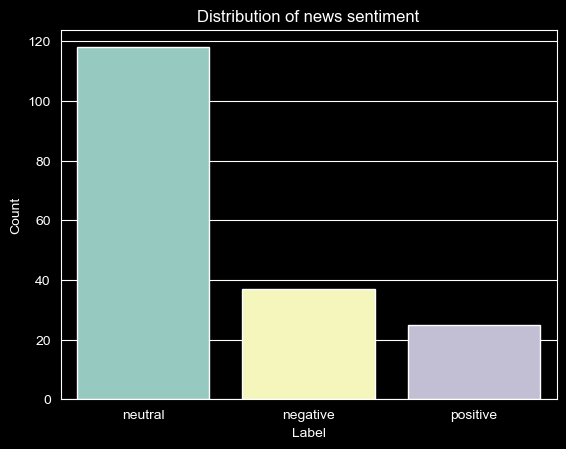

In [9]:
sns.countplot(data=news_df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [34]:
news_df['published date'].head()

0    Mon, 23 Mar 2026 13:45:00 GMT
1    Mon, 23 Mar 2026 15:30:10 GMT
2    Mon, 23 Mar 2026 18:18:24 GMT
3    Mon, 23 Mar 2026 11:24:00 GMT
4    Mon, 23 Mar 2026 14:59:25 GMT
Name: published date, dtype: object

In [35]:
news_df.index=pd.to_datetime(news_df['published date'])

In [36]:
news_df.head()

,title,description,published date,url,publisher,label,confidence
published date,,,,,,,
2026-03-23 13:45:00,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",neutral,0.855668
2026-03-23 15:30:10,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.604526
2026-03-23 18:18:24,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N...",neutral,0.619558
2026-03-23 11:24:00,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title...",negative,0.784126
2026-03-23 14:59:25,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ...",neutral,0.912184


In [37]:
news_df.sort_index(inplace=True)

In [84]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=news_df.index,y=news_df['confidence'],mode='markers'))
fig.show()

In [68]:
indices = ["Nifty 50","Sensex","S&P 500","Dow Jones Industrial Average","NASDAQ Composite"]

indian_companies = ["Reliance Industries","Tata Consultancy Services","HDFC Bank","Infosys","ICICI Bank"]

us_companies = ["Apple Inc.","Microsoft","NVIDIA","Amazon","Tesla","Alphabet Inc."]
for name in indices:
    __=pd.DataFrame(acquire_news_keyword(topic=name,results=100))
    __['time_of_collection']=datetime.now().strftime('%Y-%m-%d %H:%M')
    record_news(new_news=__,ticker=name,header=True)
    del __


In [65]:
files = os.listdir(path)
files

['Alphabet Inc..csv',
 'Amazon.csv',
 'Apple Inc..csv',
 'HDFC Bank.csv',
 'ICICI Bank.csv',
 'Infosys.csv',
 'Microsoft.csv',
 'msftn.csv',
 'Nifty 50.csv',
 'NVIDIA.csv',
 'Reliance Industries.csv',
 'Sensex.csv',
 'Tata Consultancy Services.csv',
 'Tesla.csv']

In [76]:
sp_df=pd.read_csv(path+'\S&P 500.csv')
sp_df.head()

,title,description,published date,url,publisher,time_of_collection
0,"Inside the Turmoil at RFK Jr.’s CDC, as Told b...","Inside the Turmoil at RFK Jr.’s CDC, as Told b...","Mon, 23 Mar 2026 12:44:55 GMT",https://news.google.com/rss/articles/CBMilgFBV...,"{'href': 'https://www.nytimes.com', 'title': '...",2026-03-24 22:37
1,View Exterior Photos of the 2027 Mercedes-Mayb...,View Exterior Photos of the 2027 Mercedes-Mayb...,"Tue, 24 Mar 2026 13:02:08 GMT",https://news.google.com/rss/articles/CBMipAFBV...,"{'href': 'https://www.caranddriver.com', 'titl...",2026-03-24 22:37
2,AI Is Hitting the Sweet Part of the S-Curve - ...,AI Is Hitting the Sweet Part of the S-Curve B...,"Tue, 24 Mar 2026 10:30:04 GMT",https://news.google.com/rss/articles/CBMingFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-24 22:37
3,"Janice S. Flynn Obituary March 22, 2026 - Meng...","Janice S. Flynn Obituary March 22, 2026 - Meng...","Sun, 22 Mar 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiZkFVX...,"{'href': 'https://www.mengfuneralhome.com', 't...",2026-03-24 22:37
4,"Empty offices, vacant storefronts raise stakes...","Empty offices, vacant storefronts raise stakes...","Mon, 23 Mar 2026 16:00:00 GMT",https://news.google.com/rss/articles/CBMilAFBV...,"{'href': 'https://www.washingtonpost.com', 'ti...",2026-03-24 22:37


In [74]:
nifty_df=pd.read_csv(path+"\\NIFTY 50.csv")
nifty_df.head()

,title,description,published date,url,publisher,time_of_collection
0,"Stock market today (March 24, 2026): Nifty50 e...","Stock market today (March 24, 2026): Nifty50 e...","Tue, 24 Mar 2026 03:48:00 GMT",https://news.google.com/rss/articles/CBMi2gJBV...,{'href': 'https://timesofindia.indiatimes.com'...,2026-03-24 22:15
1,Trade setup for March 24: Will NIFTY50 sustain...,Trade setup for March 24: Will NIFTY50 sustain...,"Tue, 24 Mar 2026 00:20:10 GMT",https://news.google.com/rss/articles/CBMixwFBV...,"{'href': 'https://upstox.com', 'title': 'Upstox'}",2026-03-24 22:15
2,Closing Bell: Markets bounce back; Nifty above...,Closing Bell: Markets bounce back; Nifty above...,"Tue, 24 Mar 2026 10:41:24 GMT",https://news.google.com/rss/articles/CBMikwJBV...,"{'href': 'https://www.moneycontrol.com', 'titl...",2026-03-24 22:15
3,Trade setup for March 24: Top 15 things to kno...,Trade setup for March 24: Top 15 things to kno...,"Mon, 23 Mar 2026 17:39:50 GMT",https://news.google.com/rss/articles/CBMiggJBV...,"{'href': 'https://www.moneycontrol.com', 'titl...",2026-03-24 22:15
4,India's Nifty 50 closes 2.5% higher as long-aw...,India's Nifty 50 closes 2.5% higher as long-aw...,"Mon, 02 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMikAFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}",2026-03-24 22:15


In [75]:
nv_df=pd.read_csv(path+"\\NVIDIA.csv")
nv_df.head()

,title,description,published date,url,publisher,time_of_collection
0,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,Nvidia’s Jensen Huang Says He Thinks ‘We’ve Ac...,"Mon, 23 Mar 2026 23:37:35 GMT",https://news.google.com/rss/articles/CBMisAFBV...,"{'href': 'https://www.forbes.com', 'title': 'F...",2026-03-24 22:29
1,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,Nvidia CEO Jensen Huang says ‘I think we’ve ac...,"Mon, 23 Mar 2026 19:42:33 GMT",https://news.google.com/rss/articles/CBMiigFBV...,"{'href': 'https://www.theverge.com', 'title': ...",2026-03-24 22:29
2,NVIDIA CEO Jensen Huang says AGI is here — sor...,NVIDIA CEO Jensen Huang says AGI is here — sor...,"Tue, 24 Mar 2026 16:11:53 GMT",https://news.google.com/rss/articles/CBMifEFVX...,"{'href': 'https://mashable.com', 'title': 'Mas...",2026-03-24 22:29
3,Super Micro’s Fate Lies in Nvidia’s Hands - WSJ,Super Micro’s Fate Lies in Nvidia’s Hands WSJ,"Tue, 24 Mar 2026 09:30:00 GMT",https://news.google.com/rss/articles/CBMikANBV...,"{'href': 'https://www.wsj.com', 'title': 'WSJ'}",2026-03-24 22:29
4,Microsoft and Nvidia team up on AI nuclear pus...,Microsoft and Nvidia team up on AI nuclear pus...,"Tue, 24 Mar 2026 16:03:38 GMT",https://news.google.com/rss/articles/CBMif0FVX...,"{'href': 'https://www.axios.com', 'title': 'Ax...",2026-03-24 22:29
